# Análisis exploratorio de incidencia delictiva en México

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

Hice lo siguiente porque se me descompuso el archivo original porque lo guardé mal o algo.

In [42]:
url = 'https://github.com/EdXisRosNez/limpieza_datos_y_eda_EARJ/raw/refs/heads/main/data/datos_delitos.csv'
df = pd.read_csv(url, encoding='ISO-8859-1')
df.to_csv('data/datos_delitos.csv', index=False)


In [43]:
df = pd.read_csv('data/delitos.csv')

# Creo que es este porque en el anterior ni se encuentra la palabra "doloso"
df = pd.read_csv('data/datos_delitos.csv', encoding='ISO-8859-1')
df = pd.read_csv('data/datos_delitos.csv')
df.columns
def limpiar_columnas(df:pd.DataFrame):
    columnas_limpias = []
    for col in df.columns:
        # convertir a minusculas, reemplazar espacios por guiones bajos y eliminar caracteres especiales
        col = col.lower().replace(" ", "_").replace("ñ", "ni").replace(".", "").replace("á", "a").replace("é", "e").replace("í","i").replace("ó", "o").replace("ú", "u").replace("(", "").replace(")", "")
        columnas_limpias.append(col)
    
    df.columns = columnas_limpias

    return df

df = limpiar_columnas(df)
df.columns
# df.sample(20)

Index(['anio', 'clave_ent', 'entidad', 'bien_juridico_afectado',
       'tipo_de_delito', 'subtipo_de_delito', 'modalidad', 'enero', 'febrero',
       'marzo', 'abril', 'mayo', 'junio', 'julio', 'agosto', 'septiembre',
       'octubre', 'noviembre', 'diciembre'],
      dtype='object')

#### Ejercicio 1: Elige 3 estados de la república y grafica una serie de tiempo de la frecuencia abosluta de homicidios dolosos de enero 2015 a julio 2019 en estas tres entidades

Primero verificaré si hay valores NA. Si sí, los eliminaré.

In [44]:
df.isna().any() # Sí hay
df = df.dropna()
df.isna().any() # Ya no hay

anio                      False
clave_ent                 False
entidad                   False
bien_juridico_afectado    False
tipo_de_delito            False
subtipo_de_delito         False
modalidad                 False
enero                     False
febrero                   False
marzo                     False
abril                     False
mayo                      False
junio                     False
julio                     False
agosto                    False
septiembre                False
octubre                   False
noviembre                 False
diciembre                 False
dtype: bool

Derretimos los datos con
<span style="background-color: #F15966; color: white; padding: 2px;font-weight: bold;">melt</span>
para ver la frecuencia de cada columna en id_vars

In [45]:
df_ej1 = df.melt(id_vars=['anio', 'clave_ent', 'entidad', 
                          'bien_juridico_afectado','tipo_de_delito', 
                          'subtipo_de_delito', 'modalidad'],
                     var_name='nombre_mes',
                     value_name='frecuencia')
df_ej1

,anio,clave_ent,entidad,bien_juridico_afectado,tipo_de_delito,subtipo_de_delito,modalidad,nombre_mes,frecuencia
0,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,enero,3.0
1,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,enero,1.0
2,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,enero,0.0
3,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,enero,2.0
4,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio culposo,Con arma de fuego,enero,0.0
...,...,...,...,...,...,...,...,...,...
338683,2023,32,Zacatecas,Otros bienes jurídicos afectados (del fuero co...,Falsificación,Falsificación,Falsificación,diciembre,2.0
338684,2023,32,Zacatecas,Otros bienes jurídicos afectados (del fuero co...,Contra el medio ambiente,Contra el medio ambiente,Contra el medio ambiente,diciembre,0.0
338685,2023,32,Zacatecas,Otros bienes jurídicos afectados (del fuero co...,Delitos cometidos por servidores públicos,Delitos cometidos por servidores públicos,Delitos cometidos por servidores públicos,diciembre,8.0
338686,2023,32,Zacatecas,Otros bienes jurídicos afectados (del fuero co...,Electorales,Electorales,Electorales,diciembre,0.0


Como solamente nos importan los homocidios dolosos, filtramos el dataframe

In [46]:
df_ej1 = df_ej1[df_ej1.subtipo_de_delito == 'Homicidio doloso']
df_ej1.sample(5)

,anio,clave_ent,entidad,bien_juridico_afectado,tipo_de_delito,subtipo_de_delito,modalidad,nombre_mes,frecuencia
169835,2015,6,Colima,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,julio,0.0
66052,2018,3,Baja California Sur,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,marzo,17.0
142493,2015,15,México,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,junio,28.0
211486,2019,15,México,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,agosto,46.0
134655,2021,31,Yucatán,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,mayo,0.0


Definimos los estados que nos interesan y nuevamente filtramos el dataframe; asímismo, eliminamos las columnas que no nos interesan.

In [47]:
estados_interes = ["Nuevo León", "Sonora", "Quintana Roo"]
anio_frec_df = df_ej1[["anio", "entidad", "frecuencia"]]
anio_frec_df = anio_frec_df[
    anio_frec_df["entidad"].isin(estados_interes)
    ]
anio_frec_df.sample(15)


,anio,entidad,frecuencia
265580,2018,Quintana Roo,43.0
158957,2020,Quintana Roo,5.0
240101,2019,Nuevo León,8.0
334181,2022,Nuevo León,6.0
11172,2018,Nuevo León,34.0
205996,2017,Quintana Roo,25.0
249902,2022,Quintana Roo,0.0
302822,2021,Nuevo León,7.0
221971,2022,Sonora,8.0
17447,2020,Nuevo León,0.0


Graficando los datos

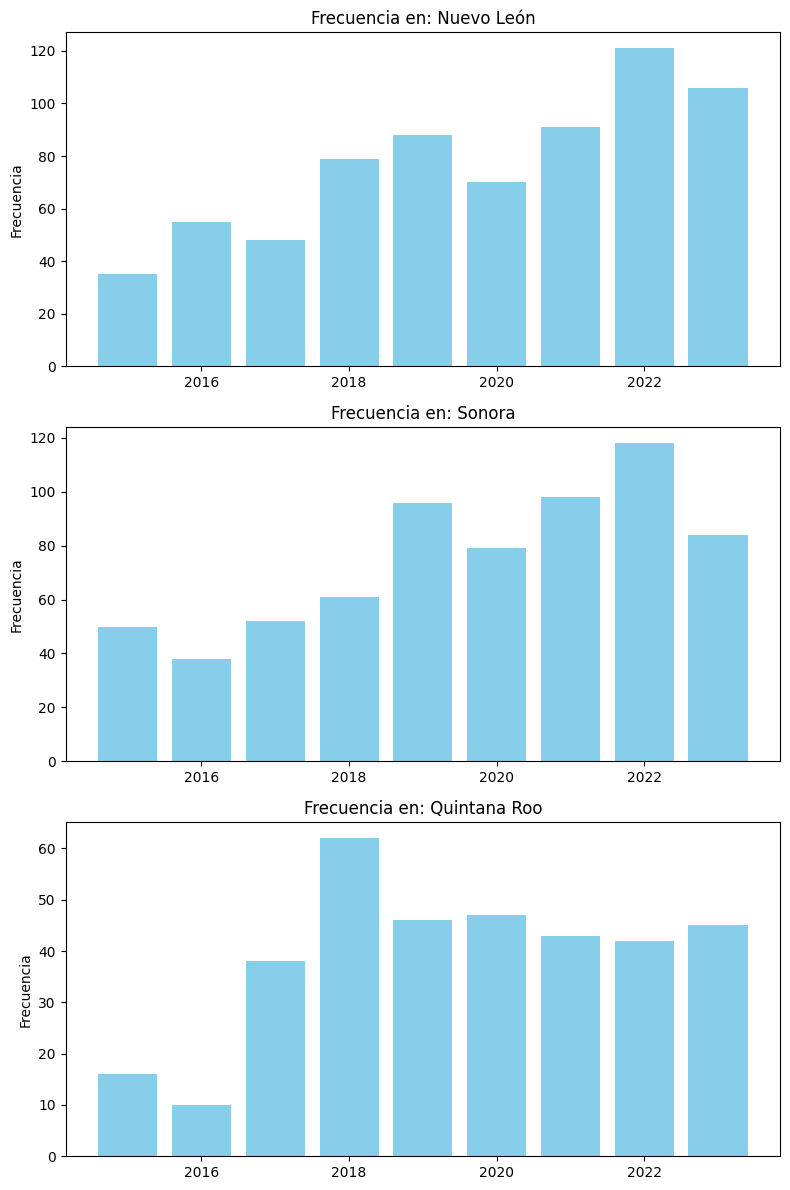

In [48]:
# Le pedí a Gémini que mejorara este código
# for i in range(3):
#     plt.bar(anio_frec_df[anio_frec_df.entidad == estados_interes[i]].anio, 
#             anio_frec_df[anio_frec_df.entidad == estados_interes[i]].frecuencia)
#     plt.show()


# Creamos la figura con 3 espacios (filas=3, columnas=1)
fig, axes = plt.subplots(3, 1, figsize=(8, 12))

for i in range(3):
    # Seleccionamos los datos
    datos = anio_frec_df[anio_frec_df.entidad == estados_interes[i]]
    
    # Graficamos en el 'eje' correspondiente (axes[i])
    axes[i].bar(datos.anio, datos.frecuencia, color='skyblue')
    
    # Personalizamos cada gráfica
    axes[i].set_title(f"Frecuencia en: {estados_interes[i]}")
    axes[i].set_ylabel("Frecuencia")

plt.tight_layout() # Ajusta el espacio para que no se encimen los títulos
# plt.show()

#### Ejercicio 2: Contesta las siguientes  preguntas:
1. ¿Cuántos homicidios dolosos hubo en Colima en el 2018?
2. ¿Cuantos robos de vehículo automotor ha habido en el 2019?
3. Obten la suma de homicidos dolosos y feminidios en toda la República Mexicana en cada año.
4. ¿En qué mes y en qué municipio ha ocurrido el mayor número de feminicidios?
5. ¿En qué año y en qué estado ha ocurrido el mayor número de feminicidios?

##### 1. ¿Cuántos homicidios dolosos hubo en Colima en el 2018?

In [49]:
df_ej2 = df.melt(id_vars=['anio', 'clave_ent', 'entidad', 
                          'bien_juridico_afectado','tipo_de_delito', 
                          'subtipo_de_delito', 'modalidad'],
                     var_name='nombre_mes',
                     value_name='frecuencia')

dolosos_Colima_2018_df = df_ej2[(df_ej2.anio == 2018) & 
                             (df_ej2.subtipo_de_delito == 'Homicidio doloso') &
                             (df_ej2.entidad == 'Colima')]

n_dolosos_Colima_2018 = dolosos_Colima_2018_df.frecuencia.sum()
print("En el 2018 han habido", int(n_dolosos_Colima_2018), "homicidos dolosos en Colima")

En el 2018 han habido 617 homicidos dolosos en Colima


##### 2. ¿Cuantos robos de vehículo automotor ha habido en el 2019?

In [50]:
# Para ver cómo se llama exactamente el subtipo de delito
df_ej2.subtipo_de_delito.unique()
robos_vehic_2019_df = df_ej2[(df_ej2.anio == 2019) &
                             (df_ej2.subtipo_de_delito == "Robo de vehículo automotor")]
robos_vehic_2019_df.sample(15)

n_robos_vehic_2019 = df_ej2.frecuencia.sum()
print("En el 2019 han habido", int(n_robos_vehic_2019), "robos de vehículos automotores en todo el país")

En el 2019 han habido 17623520 robos de vehículos automotores en todo el país


##### 3. Obten la suma de homicidos dolosos y feminidios en toda la República Mexicana en cada año.


In [51]:
n_hom_dolosos_y_fem = df_ej2[
    df_ej2.subtipo_de_delito.isin(['Homicidio doloso', 'Feminicidio'])
    ].frecuencia.sum()
n_hom_dolosos_y_fem

np.float64(235913.0)

##### 4. ¿En qué mes y en qué municipio ha ocurrido el mayor número de feminicidios?

Resolviéndolo como lo entendí.

In [52]:
feminicidios_df = df_ej2[df_ej2.subtipo_de_delito == 'Feminicidio']
feminicidios_df.sample(16)
max_frec_mes_ent = feminicidios_df[feminicidios_df.frecuencia == feminicidios_df.frecuencia.max()]
max_frec_mes_ent

,anio,clave_ent,entidad,bien_juridico_afectado,tipo_de_delito,subtipo_de_delito,modalidad,nombre_mes,frecuencia
96942,2018,30,Veracruz de Ignacio de la Llave,La vida y la Integridad corporal,Feminicidio,Feminicidio,Con otro elemento,abril,16.0
217776,2021,15,México,La vida y la Integridad corporal,Feminicidio,Feminicidio,Con otro elemento,agosto,16.0


Tenemos dos casos en los que la frecuencia fue máxima. En el primero, vemos que en abril de 2018, Veracruz, hubo 16 feminicidios; en el segundo caso, al parecer fue en la CDMX en el mes de agosto. Ambos con una frecuencia de 16 y no se especifica el municipio.
Lo que resolví fue algo puntual en un contexto histórico, por así decirlo.

Le pasé a Gémini la pregunta con mi respuesta para ver si estaba respondiendo bien; pero respondió lo siguiente.  `<br> para "enter" o doble espacio al final de las líneas`.  
Lo que vi en la segunda línea de código, fueron las siguientes observaciones:

<!-- <div style="overflow-x: auto; overflow-y: hidden; width: 100%;"> FUNCIONA IGUAL -->
<div style="overflow-x: auto; overflow-y: hidden; width: 100%;">
<!-- <div style="overflow-x: auto; white-space: nowrap; padding: 10px 0;"> -->

$$
\begin{aligned}
&\texttt{conteo\_por\_lugar} = \\
&\texttt{feminicidios\_df.groupby(} 
\underbrace{
    \texttt{['entidad', 'nombre\_mes']}
    }_{\begin{matrix}
    \text{Qué columnas} \\ \text{se agruparán}
    \end{matrix}}
\texttt{)[}
\overbrace{
    \texttt{['frecuencia', 'modalidad']}
    }^{\begin{matrix}
    \text{Columnas para} \\ \text{mapear}
    \end{matrix}}
\texttt{].}
\underbrace{
    \texttt{sum()}
    }_{\text{Mapeo}}
\texttt{.}
\overbrace{
    \texttt{reset\_index()}
    }^{\begin{matrix}
    \text{\small{Sirve para que entidad}} \\ \text{\small{se vea como:}}\\ \text{Valor }x_1 \\ \text{Valor }x_2 \\
    \text{Valor }x_3 \\ \vdots \\ \text{Valor }x_{n}
    \end{matrix}}
\end{aligned}
$$

</div>

`groupby` sirve para agrupar por filas agrupadas cada valor de la dimensión.

In [53]:
# 1. Filtramos por el delito de interés
feminicidios_df = df_ej2[df_ej2.subtipo_de_delito == 'Feminicidio']

# 2. Agrupamos por entidad y mes, sumando la frecuencia
# Esto evita errores si un municipio tiene varios registros en un mismo mes
conteo_por_lugar = feminicidios_df.groupby(['entidad', 'nombre_mes', 'anio'])[['frecuencia', 'modalidad']].sum().reset_index()

# 3. Localizamos la fila con el valor máximo total
id_max_frec = conteo_por_lugar['frecuencia'].idxmax()
resultado = conteo_por_lugar.loc[id_max_frec]


print(resultado)
# conteo_por_lugar.head(50)

entidad                                                  México
nombre_mes                                               agosto
anio                                                       2021
frecuencia                                                 19.0
modalidad     Con arma de fuegoCon arma blancaCon otro eleme...
Name: 1743, dtype: object


De la tabla anterior, podemos ver que en el mes de agosto del año de 2021, hubieron 16 feminicidios en México.

##### 5. ¿En qué año y en qué estado ha ocurrido el mayor número de feminicidios?

In [54]:
conteo_por_año = feminicidios_df.groupby(['entidad', 'anio'])['frecuencia'].sum().reset_index()
conteo_por_año
id_max_frec = conteo_por_año['frecuencia'].idxmax()
res = conteo_por_año["frecuencia"][id_max_frec]
res = conteo_por_año.loc[id_max_frec]
res

entidad       México
anio            2020
frecuencia     151.0
Name: 149, dtype: object

Podemos observar que en el año 2020 en México hubieron 151 feminicidios.

---
#### Ejercicio 3: Haz una gráfica de pastel de tipos de delito. Deberás crear una gráfica para cada año. Utiliza la función subplots de matplotlib

Primero agruparemos los años con cada tipo de delito de un dataframe derretido (para las frecuencias).

In [66]:
df_ej3 = df.melt(id_vars=['anio', 'clave_ent', 'entidad', 
                          'bien_juridico_afectado','tipo_de_delito', 
                          'subtipo_de_delito', 'modalidad'],
                     var_name='nombre_mes',
                     value_name='frecuencia')
df_año_tipodel = df_ej3.groupby(["anio", "tipo_de_delito"])['frecuencia'].sum().reset_index()
df_año_tipodel


,anio,tipo_de_delito,frecuencia
0,2015,Aborto,544.0
1,2015,Abuso de confianza,20013.0
2,2015,Abuso sexual,11980.0
3,2015,Acoso sexual,1109.0
4,2015,Allanamiento de morada,12326.0
...,...,...,...
355,2023,Tráfico de menores,12.0
356,2023,Violación equiparada,7109.0
357,2023,Violación simple,15622.0
358,2023,Violencia de género en todas sus modalidades d...,6406.0


Extraemos los años para poder saber cuántas gráficas serán.


In [67]:
anios = df_año_tipodel.anio.unique()
anios


array([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])

Hacemos una prueba de una gráfica para el año 2015.

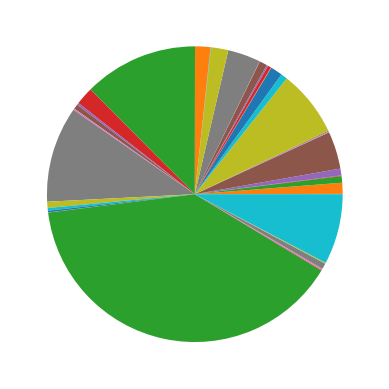

In [74]:
datos_2015 = df_año_tipodel[df_año_tipodel.anio == 2015]
frec_datos_2015 = datos_2015.frecuencia
plt.pie(frec_datos_2015)
plt.show()

Haciendo la gráfica de todos los años con diferentes gráficas de pastel (lo que yo solo logré).

/tmp/ipykernel_28724/2345089150.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


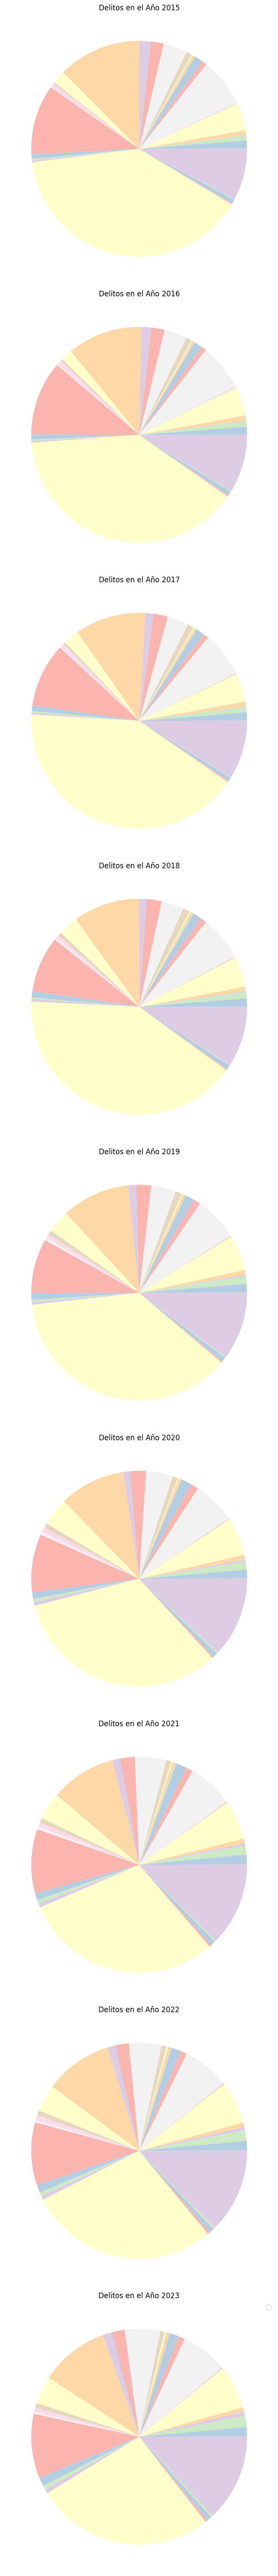

In [ ]:
n_anios = len(anios)
fig, axes = plt.subplots(n_anios, 1, figsize=(15, 60))
for i, anio in enumerate(anios):
    datos_anio = df_año_tipodel[df_año_tipodel['anio'] == anio]
    
    axes[i].pie(datos_anio.frecuencia,
                colors=plt.cm.Pastel1.colors,
                )
    
    axes[i].set_title(f"Delitos en el Año {anio}")

plt.legend()
plt.tight_layout()
plt.show()


Mejorando lo anterior con ayuda de Gémini para que se mostraran las leyendas.

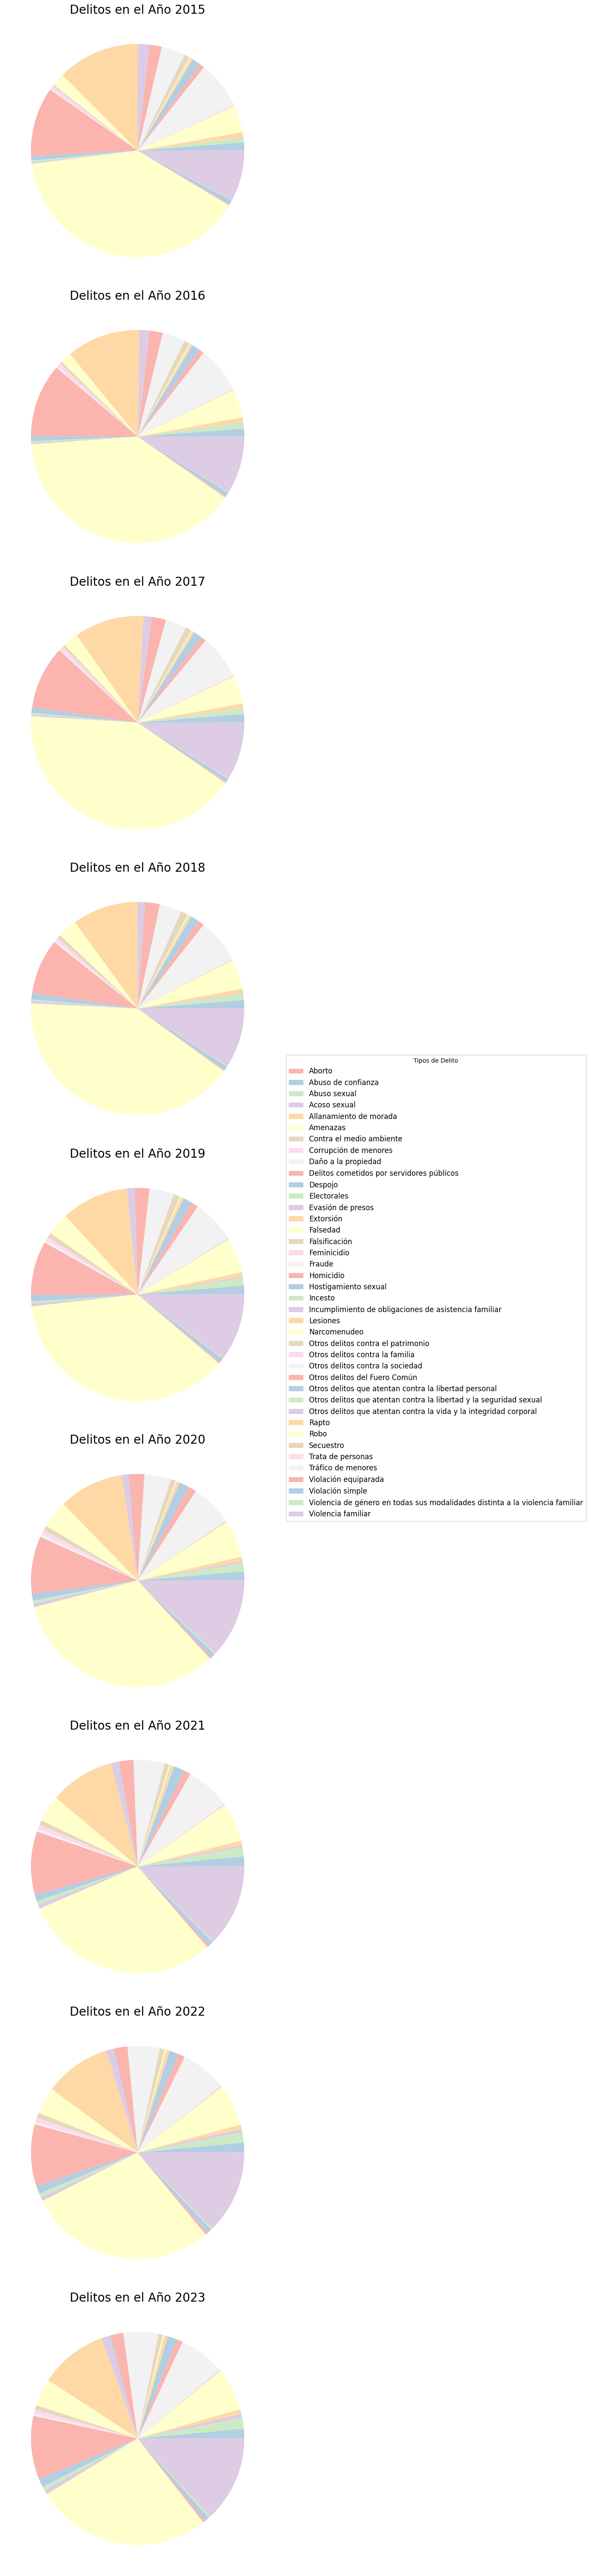

In [ ]:
n_anios = len(anios)
# Aumentamos un poco el figsize para dar espacio a la leyenda
fig, axes = plt.subplots(n_anios, 1, figsize=(15, 60))

for i, anio in enumerate(anios):
    datos_anio = df_año_tipodel[df_año_tipodel['anio'] == anio]
    
    # Guardamos el resultado del pie en variables
    # wedges son los trozos de la gráfica (necesarios para la leyenda)
    wedges, texts = axes[i].pie(datos_anio.frecuencia,
                                colors=plt.cm.Pastel1.colors)
    
    axes[i].set_title(f"Delitos en el Año {anio}", fontsize=20)

# Creamos la leyenda general usando los wedges del último gráfico 
# y los nombres de los delitos (labels)
fig.legend(wedges, df_año_tipodel['tipo_de_delito'].unique(), 
           title="Tipos de Delito",
           loc="center right",        # Posición
           bbox_to_anchor=(1.2, 0.5), # La saca un poco de la gráfica para que no estorbe
           fontsize=12)

plt.tight_layout()
plt.show()

---
#### Calcula la tasa por 100,000 habitantes
##### Tasa por 100,000 habitantes
Mostrar el total de delitos en una entidad no nos sirve de mucho. Es mucho más útil calcular la tasa de incidencia delictiva por cada 100,000 habitantes

$$
tasa = \frac{delitos\space totales}{población} \times 100,000
$$

Esta tasa la podemos anualizar multiplicándola por un factor de 12
$$
tasa\space anualizada = tasa \times 12
$$

Población por entidad federativa según [la encuesta intercensal 2015](https://www.inegi.org.mx/programas/intercensal/2015/)

No tienes que descargar nada. Ya están los datos en la carpeta data

In [118]:
pobs = pd.read_csv('data/poblacion_entidades_2015.csv', encoding='iso-8859-1', sep=";")
pobs = pobs[['Cve_Entidad', 'Entidad', 'Poblacion']]
pobs = pobs.rename(columns={'Cve_Entidad':'clave_entidad', 'Entidad':'entidad', 'Poblacion':'poblacion'})
pobs.head(10)

,clave_entidad,entidad,poblacion
0,1,Aguascalientes,1312544.0
1,2,Baja California,3315766.0
2,3,Baja California Sur,712029.0
3,4,Campeche,899931.0
4,5,Coahuila de Zaragoza,5217908.0
5,6,Colima,3556574.0
6,7,Chiapas,8918653.0
7,8,Chihuahua,2954915.0
8,9,Ciudad de México,711235.0
9,10,Durango,1754754.0


In [154]:
df_ej4 = df.melt(id_vars=['anio', 'clave_ent', 'entidad', 
                          'bien_juridico_afectado','tipo_de_delito', 
                          'subtipo_de_delito', 'modalidad'],
                     var_name='nombre_mes',
                     value_name='frecuencia_delito')[['entidad', 'frecuencia_delito']]

delitos_por_entidad_df = df_ej4.groupby('entidad')['frecuencia_delito'].sum().reset_index()
delitos_por_entidad_df
tasa_anualizada = (delitos_por_entidad_df.frecuencia_delito / pobs.poblacion) * 100000
delitos_por_entidad_df['tasa_anualizada'] = tasa_anualizada
delitos_por_entidad_df




,entidad,frecuencia_delito,tasa_anualizada
0,Aguascalientes,308909.0,23535.134822
1,Baja California,968873.0,29220.186225
2,Baja California Sur,196543.0,27603.229644
3,Campeche,69647.0,7739.148890
4,Chiapas,186853.0,3580.994529
5,Chihuahua,615774.0,17313.684462
6,Ciudad de México,1926381.0,21599.461264
7,Coahuila de Zaragoza,492254.0,16658.820981
8,Colima,205793.0,28934.599675
9,Durango,262505.0,14959.646765
